# Character-Level GPT on TinyStories — From-Scratch Implementation



## 0. Environment Setup

In [ ]:
%pip install -q datasets ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00


### 0.1 Imports

In [ ]:
import os, re, sys, json, math, time, random, hashlib, logging, platform, subprocess, unicodedata
from collections import Counter
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import datasets
import ftfy
from datasets import load_dataset

### 0.2 Device and Mixed Precision

The run uses bfloat16 autocast on Ampere or newer GPUs. On older cards such as the T4 or V100, it uses float16 with a gradient scaler. TF32 is turned on for the float32 matmuls that remain.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  "
          f"memory: {torch.cuda.get_device_properties(0).total_memory / 2**30:.1f} GiB  |  amp: {amp_dtype}")
else:
    amp_dtype = torch.float32
    print("No GPU found, running on CPU")


def amp_ctx():
    return torch.autocast(device_type="cuda", dtype=amp_dtype) if device == "cuda" else nullcontext()


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

GPU: NVIDIA A100-SXM4-40GB  |  memory: 39.5 GiB  |  amp: torch.bfloat16


### 0.3 Run Configuration

The default model has 8 layers, 8 heads, 512-dim embeddings and a 512-character context, about 25.5M parameters. Each optimizer step sees 64 × 512 = 32,768 characters. A first run with 6 layers × 384 dims and a 256-character context reached a validation loss of 0.544 nats/char, with the loss still falling and a train/val gap of only 0.016, which shows the smaller model was capacity-limited. The 512-character context also gives the model more of each story (about 890 characters on average) at once.

All outputs go into the team repository layout on Google Drive, so they survive a Colab disconnect:

```
team-repo/
├── task1_llm/
│   ├── data/                       dataset source note
│   └── <member_name>/
│       ├── src/                    this notebook, saved with its outputs
│       ├── data_processed/         vocab, split indices, encoded corpora
│       ├── checkpoints/            ckpt_best.pt, ckpt_last.pt
│       ├── outputs/                samples, plots, metric tables, human-audit sheet
│       ├── metrics_report.csv
│       ├── failure_analysis.md
│       └── results.md
└── reproducibility/
    ├── manifests/                  manifest, environment file, library versions (one set per run)
    └── raw_logs/                   untouched runlog.txt (one per run)
```

Set `member_name` to your own name before running.

In [ ]:
@dataclass
class Config:
    dataset_name: str = "roneneldan/TinyStories"
    seed: int = 1337
    n_train_stories: int = 100_000
    n_val_stories: int = 10_000
    min_story_chars: int = 50
    min_char_freq: int = 20

    block_size: int = 512
    n_layer: int = 8
    n_head: int = 8
    n_embd: int = 512
    dropout: float = 0.1

    epochs: int = 10
    batch_size: int = 64
    peak_lr: float = 8e-4
    min_lr: float = 8e-5
    warmup_frac: float = 0.03
    weight_decay: float = 0.1
    beta1: float = 0.9
    beta2: float = 0.95
    grad_clip: float = 1.0
    spike_factor: float = 1.3

    log_every: int = 50
    eval_interval: int = 500
    eval_batches: int = 40
    final_train_eval_batches: int | None = None
    keep_epoch_weights: bool = False
    compile: bool = True
    repo_root: str = "/content/drive/MyDrive/team-repo"
    member_name: str = "pratiksha_kaushik"


cfg = Config()
set_seed(cfg.seed)
pd.Series(asdict(cfg), name="value").to_frame()

,value
dataset_name,roneneldan/TinyStories
seed,1337
n_train_stories,100000
n_val_stories,10000
min_story_chars,50
min_char_freq,20
block_size,512
n_layer,8
n_head,8
n_embd,512


### 0.4 Repository Folders and Raw Log

Every event (configuration, data statistics, each 50-step training line, evaluations, warnings, final metrics) goes to `reproducibility/raw_logs/task1_<member>_<run_id>_runlog.txt`. The handler only appends; nothing in the notebook rewrites or cleans the file. Each run gets its own log and manifest, so earlier runs keep their evidence trail. The member folder itself always holds the latest run. On Colab the first run asks for Drive permission once.

In [ ]:
repo_root = Path(cfg.repo_root)
if str(repo_root).startswith("/content/drive"):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except ImportError:
        repo_root = Path("team-repo")

run_id = datetime.now().strftime("%Y%m%d-%H%M%S") + f"_L{cfg.n_layer}H{cfg.n_head}C{cfg.n_embd}T{cfg.block_size}"
run_tag = f"task1_{cfg.member_name}_{run_id}"

member_dir = repo_root / "task1_llm" / cfg.member_name
SRC_DIR = member_dir / "src"
DATA_DIR = member_dir / "data_processed"
CKPT_DIR = member_dir / "checkpoints"
OUT_DIR = member_dir / "outputs"
PLOT_DIR = OUT_DIR / "plots"
SAMPLE_DIR = OUT_DIR / "samples"
TABLE_DIR = OUT_DIR / "metrics"
MANIFEST_DIR = repo_root / "reproducibility" / "manifests"
RAW_LOG_DIR = repo_root / "reproducibility" / "raw_logs"
for d in (repo_root / "task1_llm" / "data", SRC_DIR, DATA_DIR, CKPT_DIR, PLOT_DIR, SAMPLE_DIR, TABLE_DIR, MANIFEST_DIR, RAW_LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)
log_path = RAW_LOG_DIR / f"{run_tag}_runlog.txt"

log = logging.getLogger("gpt")
log.setLevel(logging.INFO)
log.handlers.clear()
log.propagate = False
fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%Y-%m-%d %H:%M:%S")
for handler in (logging.FileHandler(log_path, mode="a"), logging.StreamHandler(sys.stdout)):
    handler.setFormatter(fmt)
    log.addHandler(handler)

log.info(f"run_id={run_id}")
log.info(f"member_dir={member_dir.resolve()}")
log.info(f"raw_log={log_path.resolve()}")
log.info(f"device={device} amp_dtype={amp_dtype}")
log.info("config=" + json.dumps(asdict(cfg)))

Mounted at /content/drive
2026-10-05 22:39:46 | INFO    | run_id=20261005-223946_L8H8C512T512
2026-10-05 22:39:46 | INFO    | member_dir=/content/drive/MyDrive/team-repo/task1_llm/pratiksha_kaushik
2026-10-05 22:39:46 | INFO    | raw_log=/content/drive/MyDrive/team-repo/reproducibility/raw_logs/task1_pratiksha_kaushik_20261005-223946_L8H8C512T512_runlog.txt
2026-10-05 22:39:46 | INFO    | device=cuda amp_dtype=torch.bfloat16
2026-10-05 22:39:46 | INFO    | config={"dataset_name": "roneneldan/TinyStories", "seed": 1337, "n_train_stories": 100000, "n_val_stories": 10000, "min_story_chars": 50, "min_char_freq": 20, "block_size": 512, "n_layer": 8, "n_head": 8, "n_embd": 512, "dropout": 0.1, "epochs": 10, "batch_size": 64, "peak_lr": 0.0008, "min_lr": 8e-05, "warmup_frac": 0.03, "weight_decay": 0.1, "beta1": 0.9, "beta2": 0.95, "grad_clip": 1.0, "spike_factor": 1.3, "log_every": 50, "eval_interval": 500, "eval_batches": 40, "final_train_eval_batches": null, "keep_epoch_weights": false, "co

### 0.5 Environment File and Library Versions

In [ ]:
env_info = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version() if device == "cuda" else None,
    "gpu": torch.cuda.get_device_name(0) if device == "cuda" else None,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "datasets": datasets.__version__,
    "ftfy": ftfy.__version__,
    "amp_dtype": str(amp_dtype),
}
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True).stdout
(MANIFEST_DIR / f"{run_tag}_requirements-lock.txt").write_text(freeze)
(MANIFEST_DIR / f"{run_tag}_env_info.json").write_text(json.dumps(env_info, indent=2))
log.info("env=" + json.dumps(env_info))
env_info

2026-10-05 22:39:48 | INFO    | env={"python": "3.13.15", "platform": "Linux-6.6.122+-x86_64-with-glibc2.39", "torch": "2.11.0+cu130", "cuda": "13.0", "cudnn": 92700, "gpu": "NVIDIA A100-SXM4-40GB", "numpy": "2.1.3", "pandas": "2.2.3", "matplotlib": "3.10.0", "datasets": "4.8.5", "ftfy": "6.3.1", "amp_dtype": "torch.bfloat16"}


{'python': '3.13.15',
 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39',
 'torch': '2.11.0+cu130',
 'cuda': '13.0',
 'cudnn': 92700,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'numpy': '2.1.3',
 'pandas': '2.2.3',
 'matplotlib': '3.10.0',
 'datasets': '4.8.5',
 'ftfy': '6.3.1',
 'amp_dtype': 'torch.bfloat16'}

## 1. Data Preprocessing

### 1.1 Load TinyStories

TinyStories (Eldan & Li, 2023) is a set of short synthetic stories written with the vocabulary of a 3–4 year old. The Hugging Face release has about 2.1M training stories and 22K validation stories, each in a single `text` field.

In [ ]:
raw = load_dataset(cfg.dataset_name, split="train")
log.info(f"loaded {cfg.dataset_name}: {len(raw):,} stories, columns={raw.column_names}")
raw

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

2026-10-05 22:40:05 | INFO    | loaded roneneldan/TinyStories: 2,119,719 stories, columns=['text']


Dataset({
    features: ['text'],
    num_rows: 2119719
})

### 1.2 A First Look at the Raw Data

In [ ]:
peek = raw.select(range(2000))["text"]
peek_len = np.array([len(t) for t in peek])
print(f"chars per story (first 2000): mean={peek_len.mean():.0f}  median={np.median(peek_len):.0f}  "
      f"min={peek_len.min()}  max={peek_len.max()}")
odd = sorted({ch for t in peek for ch in t if not ch.isascii()})
print("non-ASCII characters seen:", odd[:40])
print("-" * 80)
print(peek[0])

chars per story (first 2000): mean=850  median=777  min=274  max=4123
non-ASCII characters seen: ['¦', 'â', 'œ', '˜', '“', '”', '€', '™']
--------------------------------------------------------------------------------
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


### 1.3 Text Normalisation

The raw stories mix curly and straight quotes, use several kinds of dash, and sometimes contain stray control or zero-width characters. Some stories also contain *mojibake*: UTF-8 text that was decoded as Windows-1252 somewhere upstream, so a curly apostrophe shows up as `â€™`. `ftfy` repairs those, and the remaining characters are mapped to plain ASCII punctuation. Paragraph breaks (`\n`) are kept because they are part of the story structure. None of these changes alter the meaning of the text, and they keep the character set small.

In [ ]:
QUOTE_1 = [0x2018, 0x2019, 0x201A, 0x2032]
QUOTE_2 = [0x201C, 0x201D, 0x201E, 0x2033]
DASHES = [0x2013, 0x2014, 0x2212]
PUNCT_MAP = {c: "'" for c in QUOTE_1} | {c: '"' for c in QUOTE_2} | {c: "-" for c in DASHES}
PUNCT_MAP |= {0x2026: "...", 0x00A0: " ", 0x0009: " ", 0x000D: "\n", 0x2028: "\n", 0x2029: "\n"}

STRIP_MAP = dict.fromkeys([c for c in range(0x20) if c != 0x0A] + list(range(0x7F, 0xA0)) + list(range(0x200B, 0x2010)) + [0xFEFF])


def normalize(text):
    if not text.isascii():
        text = ftfy.fix_text(text)
    text = unicodedata.normalize("NFKC", text).replace("\r\n", "\n")
    text = text.translate(PUNCT_MAP).translate(STRIP_MAP)
    text = re.sub(r"[ ]{2,}", " ", text)
    text = re.sub(r" *\n *", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


mojibake = ("didn" + chr(0x2019) + "t").encode("utf-8").decode("cp1252")
curly = chr(0x201C) + "Hello!" + chr(0x201D) + "  said   Tom " + chr(0x2014) + " it" + chr(0x2019) + "s fun" + chr(0x2026)
assert normalize(mojibake) == "didn't", normalize(mojibake)
assert normalize("one\n\n\n\ntwo\r\nthree") == "one\n\ntwo\nthree"
print(repr(mojibake), "->", repr(normalize(mojibake)))
print(repr(curly + "\r\n\r\n\r\nThe end."), "->", repr(normalize(curly + "\r\n\r\n\r\nThe end.")))

'didnâ€™t' -> "didn't"
'“Hello!”  said   Tom — it’s fun…\r\n\r\n\r\nThe end.' -> '"Hello!" said Tom - it\'s fun...\n\nThe end.'


### 1.4 Personal Train / Validation Split (100K / 10K)

The split is drawn from the official *train* partition with this run's seed: a random permutation, then normalisation, then removal of empty or exact-duplicate stories. The first 100,000 unique stories become training data and the next 10,000 become validation data, so the two sets are disjoint. The chosen indices are saved so the split can be rebuilt exactly.

In [ ]:
need = cfg.n_train_stories + cfg.n_val_stories
perm = np.random.default_rng(cfg.seed).permutation(len(raw))
seen, kept_idx, kept_text = set(), [], []
cursor, chunk = 0, int(need * 1.1)
while len(kept_text) < need and cursor < len(perm):
    ids = perm[cursor:cursor + chunk]
    cursor += len(ids)
    for i, story in zip(ids, raw.select(ids)["text"]):
        story = normalize(story)
        if len(story) < cfg.min_story_chars or story in seen:
            continue
        seen.add(story)
        kept_idx.append(int(i))
        kept_text.append(story)
        if len(kept_text) == need:
            break
assert len(kept_text) == need, f"only {len(kept_text)} usable stories found"

train_stories, val_stories = kept_text[: cfg.n_train_stories], kept_text[cfg.n_train_stories:]
train_idx, val_idx = kept_idx[: cfg.n_train_stories], kept_idx[cfg.n_train_stories:]
assert not set(train_idx) & set(val_idx)

(DATA_DIR / "split_indices.json").write_text(json.dumps({"seed": cfg.seed, "train": train_idx, "val": val_idx}))
log.info(f"split: train={len(train_stories):,} val={len(val_stories):,} "
         f"(scanned {cursor:,} shuffled stories, seed={cfg.seed})")

2026-10-05 22:40:30 | INFO    | split: train=100,000 val=10,000 (scanned 121,000 shuffled stories, seed=1337)


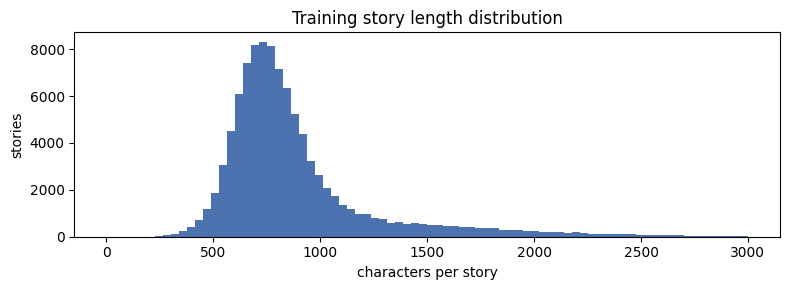

,train,val
count,100000.0,10000.0
mean,895.6,898.1
std,400.5,407.1
min,223.0,248.0
25%,671.0,671.0
50%,786.0,787.0
75%,955.0,954.0
max,4287.0,4168.0


In [ ]:
lengths = pd.DataFrame({
    "train": pd.Series([len(s) for s in train_stories]).describe(),
    "val": pd.Series([len(s) for s in val_stories]).describe(),
}).round(1)

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist([len(s) for s in train_stories], bins=80, range=(0, 3000), color="#4C72B0")
ax.set_xlabel("characters per story")
ax.set_ylabel("stories")
ax.set_title("Training story length distribution")
plt.tight_layout()
plt.savefig(PLOT_DIR / "story_lengths.png", dpi=120)
plt.show()
lengths

### 1.5 Character Vocabulary — `char_to_idx` / `idx_to_char`

The vocabulary comes from the training split only. Characters that appear fewer than `min_char_freq` times (stray emoji, foreign script) map to `<unk>`, so the model doesn't waste output capacity on them. Two special tokens are added:

- `<|eos|>` (id 0) marks story boundaries. It is placed between consecutive stories and at the start of every prompt at generation time.
- `<unk>` (id 1) stands in for any character outside the vocabulary.

In [ ]:
EOS_CHAR = "\x03"
train_text = EOS_CHAR + EOS_CHAR.join(train_stories) + EOS_CHAR
val_text = EOS_CHAR + EOS_CHAR.join(val_stories) + EOS_CHAR

codepoints, counts = np.unique(np.frombuffer(train_text.encode("utf-32-le"), dtype=np.uint32), return_counts=True)
char_counts = {chr(c): int(n) for c, n in zip(codepoints, counts) if chr(c) != EOS_CHAR}

vocab_chars = sorted(ch for ch, n in char_counts.items() if n >= cfg.min_char_freq)
dropped = {ch: n for ch, n in char_counts.items() if n < cfg.min_char_freq}

EOS_ID, UNK_ID = 0, 1
char_to_idx = {EOS_CHAR: EOS_ID}
char_to_idx.update({ch: i + 2 for i, ch in enumerate(vocab_chars)})
idx_to_char = {EOS_ID: "<|eos|>", UNK_ID: chr(0xFFFD)}
idx_to_char.update({i: ch for ch, i in char_to_idx.items() if i >= 2})
vocab_size = len(idx_to_char)

assert "\n" in char_to_idx, "paragraph breaks were lost during normalisation"
coverage = 1 - sum(dropped.values()) / sum(char_counts.values())
log.info(f"vocab_size={vocab_size} kept_chars={len(vocab_chars)} dropped_chars={len(dropped)} coverage={coverage:.6%}")
print(repr("".join(vocab_chars)))

2026-10-05 22:40:31 | INFO    | vocab_size=80 kept_chars=78 dropped_chars=21 coverage=99.999873%
'\n !"\',-./012345689:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz\xadâé†€'


### 1.6 Integer Encoding

`encode` and `decode` are the plain dictionary lookups. To encode the full corpus (about 90M characters) the same mapping is applied through a code-point lookup table in NumPy, which is much faster than a Python loop.

In [ ]:
lut = np.full(max(map(ord, char_to_idx)) + 1, UNK_ID, dtype=np.int16)
for ch, i in char_to_idx.items():
    lut[ord(ch)] = i


def encode(text):
    return [char_to_idx.get(ch, UNK_ID) for ch in text]


def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)


def encode_corpus(text):
    cps = np.frombuffer(text.encode("utf-32-le"), dtype=np.uint32)
    ids = np.full(cps.shape, UNK_ID, dtype=np.int16)
    inside = cps < lut.size
    ids[inside] = lut[cps[inside]]
    return ids


sample = train_stories[0][:120]
assert decode(encode(sample)) == sample
assert np.array_equal(encode_corpus(sample), np.array(encode(sample), dtype=np.int16))
print(encode(sample)[:30])

[37, 62, 51, 53, 3, 69, 64, 63, 62, 3, 49, 3, 68, 57, 61, 53, 7, 3, 68, 56, 53, 66, 53, 3, 71, 49, 67, 3, 49, 3]


In [ ]:
train_np, val_np = encode_corpus(train_text), encode_corpus(val_text)
train_data = torch.from_numpy(train_np).to(device)
val_data = torch.from_numpy(val_np).to(device)

data_stats = {
    "train_chars": len(train_np),
    "val_chars": len(val_np),
    "train_unk_rate": float((train_np == UNK_ID).mean()),
    "val_unk_rate": float((val_np == UNK_ID).mean()),
}
(DATA_DIR / "vocab.json").write_text(json.dumps({"idx_to_char": idx_to_char, "eos_id": EOS_ID, "unk_id": UNK_ID}, indent=1))
store_dtype = np.uint8 if vocab_size <= 256 else np.int16
np.save(DATA_DIR / "train_ids.npy", train_np.astype(store_dtype))
np.save(DATA_DIR / "val_ids.npy", val_np.astype(store_dtype))
(DATA_DIR / "dataset_stats.json").write_text(json.dumps({**data_stats, "vocab_size": vocab_size, "eos_id": EOS_ID,
                                                         "unk_id": UNK_ID, "dtype": np.dtype(store_dtype).name}, indent=2))

data_note = repo_root / "task1_llm" / "data" / "README.md"
if not data_note.exists():
    data_note.write_text(
        "# Task 1 data\n\n"
        "Source: TinyStories, https://huggingface.co/datasets/roneneldan/TinyStories (train partition, 2,119,719 stories).\n"
        "Paper: Eldan & Li (2023), https://arxiv.org/abs/2305.07759\n\n"
        "The raw dataset is not stored here; each member's notebook downloads it and writes the personal "
        "100K/10K split, vocabulary and encoded corpora to `task1_llm/<member>/data_processed/`.\n"
    )
log.info("data " + json.dumps(data_stats))
data_stats

2026-10-05 22:40:33 | INFO    | data {"train_chars": 89656644, "val_chars": 8991471, "train_unk_rate": 1.2715175910443403e-06, "val_unk_rate": 2.113113638469167e-06}


{'train_chars': 89656644,
 'val_chars': 8991471,
 'train_unk_rate': 1.2715175910443403e-06,
 'val_unk_rate': 2.113113638469167e-06}

### 1.7 Fixed-Length Input–Target Sequences

The corpus is a single stream of character ids. A training example is a window of `block_size + 1` ids. The first `block_size` ids are the input `x` and the same window shifted by one position is the target `y`, so position *t* is trained to predict character *t+1*.

Each epoch cuts the stream into non-overlapping windows. The starting offset is random (0 to `block_size − 1`) and the windows are shuffled, so every epoch covers every training character exactly once, with window boundaries that differ from one epoch to the next. Batches are gathered directly on the GPU, with no DataLoader overhead.

In [ ]:
class SequenceBatcher:
    def __init__(self, data, block_size, batch_size, seed):
        self.data, self.T, self.B = data, block_size, batch_size
        self.n_windows = (len(data) - block_size) // block_size
        self.steps_per_epoch = self.n_windows // batch_size
        self.gen = torch.Generator().manual_seed(seed)
        self.span = torch.arange(block_size + 1, device=data.device)

    def batch(self, starts):
        chunk = self.data[starts[:, None] + self.span].long()
        return chunk[:, :-1], chunk[:, 1:]

    def epoch(self):
        offset = int(torch.randint(0, self.T, (1,), generator=self.gen))
        order = torch.randperm(self.n_windows, generator=self.gen)
        starts = (offset + order * self.T).to(self.data.device)
        for s in range(self.steps_per_epoch):
            yield self.batch(starts[s * self.B:(s + 1) * self.B])


def eval_starts(data, block_size, batch_size, max_batches=None, seed=0):
    n = (len(data) - block_size) // block_size
    starts = torch.arange(n) * block_size
    if max_batches is not None and max_batches * batch_size < n:
        g = torch.Generator().manual_seed(seed)
        starts = starts[torch.randperm(n, generator=g)[: max_batches * batch_size]]
    starts = starts[: len(starts) // batch_size * batch_size]
    return starts.to(data.device)


train_batcher = SequenceBatcher(train_data, cfg.block_size, cfg.batch_size, cfg.seed)
log.info(f"windows/epoch={train_batcher.n_windows:,} steps/epoch={train_batcher.steps_per_epoch:,} "
         f"tokens/step={cfg.batch_size * cfg.block_size:,}")

2026-10-05 22:40:33 | INFO    | windows/epoch=175,109 steps/epoch=2,736 tokens/step=32,768


In [ ]:
xb, yb = next(train_batcher.epoch())
print("x shape:", tuple(xb.shape), " y shape:", tuple(yb.shape))
assert torch.equal(xb[:, 1:], yb[:, :-1])
print("x:", repr(decode(xb[0, :60].tolist())))
print("y:", repr(decode(yb[0, :60].tolist())))

x shape: (64, 512)  y shape: (64, 512)
x: 'not taken the blocks.\n\nTom and Lily felt sorry for Max. They'
y: 'ot taken the blocks.\n\nTom and Lily felt sorry for Max. They '


## 2. GPT Model Implementation

This is a pre-norm decoder-only Transformer, following the GPT-2 layout:

```
tokens ─► token embedding + positional embedding ─► dropout
       ─► N × [ x = x + MHSA(LN(x)) ;  x = x + FFN(LN(x)) ]
       ─► final LN ─► linear LM head ─► logits over the vocabulary
```

### 2.1 Layer Normalization

Each vector is normalised over its feature dimension and then given a learned scale and shift: $\mathrm{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$.

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = (x - mean).pow(2).mean(dim=-1, keepdim=True)
        return (x - mean) * torch.rsqrt(var + self.eps) * self.weight + self.bias

### 2.2 Causal Multi-Head Self-Attention

$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$, where $M_{ij} = -\infty$ for $j > i$.

One fused linear layer produces Q, K and V for all heads at once, and the result is split into `n_head` heads of size `n_embd / n_head`. A lower-triangular boolean mask, stored as a buffer, sets the scores for future positions to −∞ before the softmax, so their weights are exactly zero. The softmax runs in float32 for numerical stability under mixed precision.

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0
        self.n_head = cfg.n_head
        self.head_dim = cfg.n_embd // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.head_dim)
        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd)
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.resid_drop = nn.Dropout(cfg.dropout)
        causal = torch.tril(torch.ones(cfg.block_size, cfg.block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", causal.view(1, 1, cfg.block_size, cfg.block_size), persistent=False)

    def forward(self, x, return_weights=False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) * self.scale
        scores = scores.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        weights = F.softmax(scores.float(), dim=-1).to(v.dtype)

        out = self.attn_drop(weights) @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_drop(self.proj(out))
        return (out, weights) if return_weights else out

### 2.3 Position-wise Feed-Forward Network

Two linear layers with a GELU between them, expanding to 4× the model width and projecting back.

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.n_embd, 4 * cfg.n_embd)
        self.proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.drop(self.proj(F.gelu(self.fc(x))))

### 2.4 Transformer Block with Residual Connections

The block uses pre-norm, with LayerNorm applied before each sub-layer. The residual path stays an identity, which makes deep stacks easy to optimise without the long warm-up a post-norm Transformer needs.

In [ ]:
class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = LayerNorm(cfg.n_embd)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = LayerNorm(cfg.n_embd)
        self.ffn = FeedForward(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

### 2.5 GPT Language Model

- Learnable token embeddings `(vocab_size × n_embd)` and learnable absolute positional embeddings `(block_size × n_embd)`.
- A stack of `n_layer` blocks, then a final LayerNorm.
- A language-modelling head: a linear projection from `n_embd` to `vocab_size` that gives next-character logits at every position.

Weights are initialised from N(0, 0.02). The output projections of the residual branches are scaled by $1/\sqrt{2 \cdot n_{layer}}$ so the variance of the residual stream doesn't grow with depth (GPT-2).

In [ ]:
class GPT(nn.Module):
    def __init__(self, cfg, vocab_size):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(vocab_size, cfg.n_embd)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f = LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("proj.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layer))

    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.cfg.block_size, f"sequence length {T} exceeds block_size {self.cfg.block_size}"
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.float().view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

### 2.6 Instantiate and Count Parameters

In [ ]:
set_seed(cfg.seed)
raw_model = GPT(cfg, vocab_size).to(device)

n_params = sum(p.numel() for p in raw_model.parameters())
n_embed_params = raw_model.tok_emb.weight.numel() + raw_model.pos_emb.weight.numel()
param_table = pd.DataFrame(
    [(name, tuple(p.shape), p.numel()) for name, p in raw_model.named_parameters()],
    columns=["parameter", "shape", "count"],
)
log.info(f"parameters total={n_params:,} non_embedding={n_params - n_embed_params:,}")
print(f"total parameters: {n_params:,}   (non-embedding: {n_params - n_embed_params:,})")
param_table.head(16)

2026-10-05 22:40:34 | INFO    | parameters total=25,564,160 non_embedding=25,261,056
total parameters: 25,564,160   (non-embedding: 25,261,056)


,parameter,shape,count
0,tok_emb.weight,"(80, 512)",40960
1,pos_emb.weight,"(512, 512)",262144
2,blocks.0.ln1.weight,"(512,)",512
3,blocks.0.ln1.bias,"(512,)",512
4,blocks.0.attn.qkv.weight,"(1536, 512)",786432
5,blocks.0.attn.qkv.bias,"(1536,)",1536
6,blocks.0.attn.proj.weight,"(512, 512)",262144
7,blocks.0.attn.proj.bias,"(512,)",512
8,blocks.0.ln2.weight,"(512,)",512
9,blocks.0.ln2.bias,"(512,)",512


### 2.7 Verifying the Causal Mask

Two checks:

1. The attention weights in every head are exactly zero above the diagonal.
2. Changing future tokens leaves the logits at earlier positions unchanged. If the mask leaked, the logits before the edit point would change.

At initialisation the untrained model should also predict close to uniformly, giving a loss near $\ln(\text{vocab})$.

In [ ]:
raw_model.eval()
with torch.no_grad():
    x = torch.randint(2, vocab_size, (2, 64), device=device)
    h = raw_model.drop(raw_model.tok_emb(x) + raw_model.pos_emb(torch.arange(64, device=device)))
    _, w = raw_model.blocks[0].attn(raw_model.blocks[0].ln1(h), return_weights=True)
    upper = torch.triu(torch.ones(64, 64, dtype=torch.bool, device=device), diagonal=1)
    assert w[..., upper].abs().max().item() == 0.0
    assert torch.allclose(w.sum(-1).float(), torch.ones_like(w.sum(-1)).float(), atol=1e-3)

    cut = 40
    x_edit = x.clone()
    x_edit[:, cut:] = torch.randint(2, vocab_size, (2, 64 - cut), device=device)
    a, _ = raw_model(x)
    b, _ = raw_model(x_edit)
    assert torch.allclose(a[:, :cut], b[:, :cut], atol=1e-5)
    assert not torch.allclose(a[:, cut:], b[:, cut:])

    _, init_loss = raw_model(xb[:8], yb[:8])
raw_model.train()
log.info(f"causal mask checks passed; initial loss={init_loss.item():.4f} (ln V={math.log(vocab_size):.4f})")

2026-10-05 22:40:34 | INFO    | causal mask checks passed; initial loss=4.5314 (ln V=4.3820)


## 3. Training

### 3.1 Optimizer

AdamW with β = (0.9, 0.95). Weight decay applies only to matrices (linear weights and embeddings). Biases and LayerNorm gains are left undecayed.

In [ ]:
decay = [p for p in raw_model.parameters() if p.dim() >= 2]
no_decay = [p for p in raw_model.parameters() if p.dim() < 2]
optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": cfg.weight_decay}, {"params": no_decay, "weight_decay": 0.0}],
    lr=cfg.peak_lr, betas=(cfg.beta1, cfg.beta2), fused=(device == "cuda"),
)
scaler = torch.amp.GradScaler(device, enabled=(amp_dtype == torch.float16))
print(f"decayed tensors: {len(decay)}  non-decayed tensors: {len(no_decay)}  grad scaler: {scaler.is_enabled()}")

decayed tensors: 35  non-decayed tensors: 66  grad scaler: False


### 3.2 Learning-Rate Warm-up and Cosine Schedule

The learning rate rises linearly from 0 to `peak_lr` over the first `warmup_frac` of steps, then follows a cosine decay to `min_lr`. Warm-up keeps the early updates small while Adam's second-moment estimates are still unreliable.

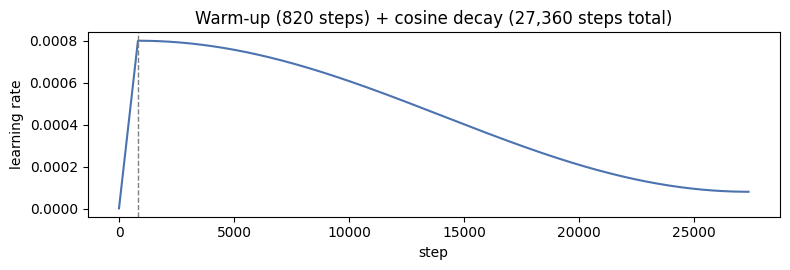

2026-10-05 22:40:39 | INFO    | total_steps=27360 warmup_steps=820


In [ ]:
total_steps = cfg.epochs * train_batcher.steps_per_epoch
warmup_steps = max(1, int(cfg.warmup_frac * total_steps))


def lr_at(step):
    if step < warmup_steps:
        return cfg.peak_lr * (step + 1) / warmup_steps
    progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
    return cfg.min_lr + 0.5 * (cfg.peak_lr - cfg.min_lr) * (1 + math.cos(math.pi * progress))


fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot([lr_at(s) for s in range(total_steps)], color="#4C72B0")
ax.axvline(warmup_steps, ls="--", c="gray", lw=1)
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.set_title(f"Warm-up ({warmup_steps} steps) + cosine decay ({total_steps:,} steps total)")
plt.tight_layout()
plt.savefig(PLOT_DIR / "lr_schedule.png", dpi=120)
plt.show()
log.info(f"total_steps={total_steps} warmup_steps={warmup_steps}")

### 3.3 Compile the Model

`torch.compile` fuses the hand-written attention and LayerNorm into far fewer kernels, which typically gives a 1.5–2× speedup. If compilation fails on a particular GPU or driver, the run falls back to eager mode.

In [ ]:
model = raw_model
if cfg.compile and device == "cuda":
    try:
        model = torch.compile(raw_model)
        with amp_ctx():
            _, warm_loss = model(xb, yb)
        warm_loss.backward()
        optimizer.zero_grad(set_to_none=True)
        log.info("torch.compile enabled")
    except Exception as err:
        model = raw_model
        optimizer.zero_grad(set_to_none=True)
        log.warning(f"torch.compile failed, using eager mode: {err!r}")

2026-10-05 22:41:11 | INFO    | torch.compile enabled


### 3.4 Evaluation Function

The evaluation function computes token-level cross-entropy, summed over every predicted character, and top-1 next-character accuracy, with dropout turned off. Mid-epoch checks use a fixed random subset of windows so the points are comparable over time. End-of-epoch checks use the full validation set.

In [ ]:
@torch.no_grad()
def evaluate(net, data, starts):
    was_training = net.training
    net.eval()
    span = torch.arange(cfg.block_size + 1, device=data.device)
    loss_sum = torch.zeros((), device=device, dtype=torch.float64)
    correct = torch.zeros((), device=device, dtype=torch.int64)
    for i in range(0, len(starts), cfg.batch_size):
        chunk = data[starts[i:i + cfg.batch_size, None] + span].long()
        x, y = chunk[:, :-1], chunk[:, 1:]
        with amp_ctx():
            logits, _ = net(x)
        logits = logits.float()
        loss_sum += F.cross_entropy(logits.view(-1, logits.size(-1)), y.reshape(-1), reduction="sum")
        correct += (logits.argmax(-1) == y).sum()
    net.train(was_training)
    n_tokens = len(starts) * cfg.block_size
    return {"loss": loss_sum.item() / n_tokens, "acc": correct.item() / n_tokens}


val_full = eval_starts(val_data, cfg.block_size, cfg.batch_size)
val_quick = eval_starts(val_data, cfg.block_size, cfg.batch_size, cfg.eval_batches, seed=1)
train_quick = eval_starts(train_data, cfg.block_size, cfg.batch_size, cfg.eval_batches, seed=2)
train_epoch_eval = eval_starts(train_data, cfg.block_size, cfg.batch_size, len(val_full) // cfg.batch_size, seed=3)
print(f"val windows: full={len(val_full):,} quick={len(val_quick):,} | train eval windows/epoch={len(train_epoch_eval):,}")

val windows: full=17,536 quick=2,560 | train eval windows/epoch=17,536


### 3.5 Training Step and Stability Monitor

Each step runs a forward pass under autocast, cross-entropy loss, backward, gradient-norm clipping at 1.0 and an AdamW update. The gradient norm is recorded *before* clipping. A step with a non-finite loss or gradient is skipped and logged. A **loss spike** is a step whose loss exceeds `spike_factor` times the exponential moving average of recent losses (checked only after warm-up).

In [ ]:
def train_step(x, y, lr):
    for group in optimizer.param_groups:
        group["lr"] = lr
    with amp_ctx():
        _, loss = model(x, y)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(raw_model.parameters(), cfg.grad_clip)
    loss_v, gn_v = loss.item(), grad_norm.item()
    finite = math.isfinite(loss_v) and math.isfinite(gn_v)
    if finite or scaler.is_enabled():
        scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)
    return loss_v, gn_v, finite

In [ ]:
class StabilityMonitor:
    def __init__(self, warmup, factor, beta=0.98):
        self.warmup, self.factor, self.beta = warmup, factor, beta
        self.ema = None
        self.spikes, self.nonfinite = [], []

    def update(self, step, loss, grad_norm, finite):
        if not finite:
            self.nonfinite.append(step)
            log.warning(f"non-finite step={step} loss={loss} grad_norm={grad_norm} (update skipped)")
            return
        if self.ema is not None and step > self.warmup and loss > self.factor * self.ema:
            self.spikes.append({"step": step, "loss": loss, "ema": self.ema})
            log.warning(f"loss spike step={step} loss={loss:.4f} ema={self.ema:.4f}")
        self.ema = loss if self.ema is None else self.beta * self.ema + (1 - self.beta) * loss

### 3.6 Checkpointing

- `ckpt_last.pt`: the full training state (model, optimizer, scaler, vocabulary), overwritten every epoch.
- `ckpt_best.pt`: the same contents, saved whenever the full validation loss improves. All reported metrics come from this checkpoint.
- `epoch_XX.pt`: model weights only for each epoch, so every row of the epoch table can be traced to a file.

In [ ]:
def save_checkpoint(path, epoch, step, metrics, full=True):
    state = {
        "model": raw_model.state_dict(),
        "config": asdict(cfg),
        "vocab": {"idx_to_char": idx_to_char, "eos_id": EOS_ID, "unk_id": UNK_ID},
        "epoch": epoch,
        "step": step,
        "metrics": metrics,
        "run_id": run_id,
    }
    if full:
        state["optimizer"] = optimizer.state_dict()
        state["scaler"] = scaler.state_dict()
    torch.save(state, path)


def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while block := f.read(chunk):
            h.update(block)
    return h.hexdigest()

### 3.7 Training Loop

Each epoch is one full pass over the training windows. The loop logs to `runlog.txt` every `log_every` steps, runs a quick train/validation check every `eval_interval` steps, and runs a full validation pass at the end of every epoch. Training throughput is measured on synchronised step times only, excluding evaluation and the first 20 steps, which include compilation.

In [ ]:
monitor = StabilityMonitor(warmup_steps, cfg.spike_factor)
steps_log, quick_evals, epoch_rows, checkpoints = [], [], [], []
step_times = []
best_val, global_step = float("inf"), 0
tokens_per_step = cfg.batch_size * cfg.block_size
step_file = open(TABLE_DIR / "step_metrics.jsonl", "w")

if device == "cuda":
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
log.info(f"training start: epochs={cfg.epochs} steps={total_steps:,} tokens/step={tokens_per_step:,}")
train_start = time.time()

2026-10-05 22:41:11 | INFO    | training start: epochs=10 steps=27,360 tokens/step=32,768


In [ ]:
for epoch in range(1, cfg.epochs + 1):
    epoch_start, epoch_loss, epoch_steps = time.time(), 0.0, 0

    for x, y in train_batcher.epoch():
        lr = lr_at(global_step)
        t0 = time.perf_counter()
        loss_v, gn_v, finite = train_step(x, y, lr)
        step_times.append(time.perf_counter() - t0)
        global_step += 1
        monitor.update(global_step, loss_v, gn_v, finite)
        if finite:
            epoch_loss += loss_v
            epoch_steps += 1

        record = {"step": global_step, "epoch": epoch, "lr": lr, "loss": loss_v, "grad_norm": gn_v}
        steps_log.append(record)
        step_file.write(json.dumps(record) + "\n")

        if global_step % cfg.log_every == 0:
            recent = step_times[-cfg.log_every:]
            log.info(f"ep {epoch:02d} step {global_step:>6}/{total_steps} loss {loss_v:.4f} "
                     f"gnorm {gn_v:.3f} lr {lr:.2e} tok/s {tokens_per_step * len(recent) / sum(recent):,.0f}")
            step_file.flush()

        if global_step % cfg.eval_interval == 0:
            tq, vq = evaluate(model, train_data, train_quick), evaluate(model, val_data, val_quick)
            quick_evals.append({"step": global_step, "train_loss": tq["loss"], "val_loss": vq["loss"]})
            log.info(f"eval step {global_step} train_loss {tq['loss']:.4f} val_loss {vq['loss']:.4f} val_acc {vq['acc']:.4f}")

    val_m = evaluate(model, val_data, val_full)
    train_m = evaluate(model, train_data, train_epoch_eval)
    row = {
        "epoch": epoch, "step": global_step,
        "train_loss_running": epoch_loss / max(1, epoch_steps),
        "train_loss": train_m["loss"], "val_loss": val_m["loss"],
        "gap": val_m["loss"] - train_m["loss"],
        "val_ppl": math.exp(val_m["loss"]), "val_bpc": val_m["loss"] / math.log(2),
        "val_acc": val_m["acc"], "lr": lr, "epoch_time_s": time.time() - epoch_start,
    }
    epoch_rows.append(row)
    log.info("epoch_end " + json.dumps({k: round(v, 5) if isinstance(v, float) else v for k, v in row.items()}))

    if cfg.keep_epoch_weights:
        path = CKPT_DIR / f"epoch_{epoch:02d}.pt"
        save_checkpoint(path, epoch, global_step, row, full=False)
        checkpoints.append({"file": str(path.relative_to(repo_root)), "epoch": epoch, "step": global_step,
                            "val_loss": row["val_loss"], "train_loss": row["train_loss"], "kind": "epoch weights"})
    save_checkpoint(CKPT_DIR / "ckpt_last.pt", epoch, global_step, row)
    if row["val_loss"] < best_val:
        best_val, best_epoch = row["val_loss"], epoch
        save_checkpoint(CKPT_DIR / "ckpt_best.pt", epoch, global_step, row, full=False)
        log.info(f"new best val_loss={best_val:.4f} at epoch {epoch} -> ckpt_best.pt")

2026-10-05 22:41:15 | INFO    | ep 01 step     50/27360 loss 2.4382 gnorm 1.131 lr 4.88e-05 tok/s 434,639
2026-10-05 22:41:18 | INFO    | ep 01 step    100/27360 loss 2.3502 gnorm 0.935 lr 9.76e-05 tok/s 450,905
2026-10-05 22:41:22 | INFO    | ep 01 step    150/27360 loss 2.2933 gnorm 0.788 lr 1.46e-04 tok/s 451,068
2026-10-05 22:41:26 | INFO    | ep 01 step    200/27360 loss 2.2609 gnorm 0.818 lr 1.95e-04 tok/s 451,047
2026-10-05 22:41:29 | INFO    | ep 01 step    250/27360 loss 2.1763 gnorm 1.108 lr 2.44e-04 tok/s 451,114
2026-10-05 22:41:33 | INFO    | ep 01 step    300/27360 loss 2.0106 gnorm 1.607 lr 2.93e-04 tok/s 451,048
2026-10-05 22:41:36 | INFO    | ep 01 step    350/27360 loss 1.8371 gnorm 1.073 lr 3.41e-04 tok/s 450,829
2026-10-05 22:41:40 | INFO    | ep 01 step    400/27360 loss 1.6346 gnorm 1.266 lr 3.90e-04 tok/s 451,006
2026-10-05 22:41:44 | INFO    | ep 01 step    450/27360 loss 1.4681 gnorm 0.930 lr 4.39e-04 tok/s 451,272
2026-10-05 22:41:47 | INFO    | ep 01 step    

In [ ]:
if device == "cuda":
    torch.cuda.synchronize()
total_train_time = time.time() - train_start
step_file.close()

steady = step_times[20:] if len(step_times) > 40 else step_times
train_tok_per_s = tokens_per_step * len(steady) / sum(steady)
peak_mem_gib = torch.cuda.max_memory_allocated() / 2**30 if device == "cuda" else float("nan")
peak_reserved_gib = torch.cuda.max_memory_reserved() / 2**30 if device == "cuda" else float("nan")

steps_df = pd.DataFrame(steps_log)
epochs_df = pd.DataFrame(epoch_rows)
evals_df = pd.DataFrame(quick_evals)
steps_df.to_csv(TABLE_DIR / "step_metrics.csv", index=False)
epochs_df.to_csv(TABLE_DIR / "epoch_metrics.csv", index=False)
evals_df.to_csv(TABLE_DIR / "quick_evals.csv", index=False)

log.info(f"training done: time={total_train_time / 60:.1f} min tok/s={train_tok_per_s:,.0f} "
         f"peak_alloc={peak_mem_gib:.2f} GiB peak_reserved={peak_reserved_gib:.2f} GiB "
         f"best_epoch={best_epoch} best_val={best_val:.4f}")
epochs_df.round(4)

2026-10-05 23:18:07 | INFO    | training done: time=36.9 min tok/s=452,013 peak_alloc=10.59 GiB peak_reserved=10.79 GiB best_epoch=10 best_val=0.4742


,epoch,step,train_loss_running,train_loss,val_loss,gap,val_ppl,val_bpc,val_acc,lr,epoch_time_s
0,1,2736,1.0368,0.6337,0.6369,0.0032,1.8907,0.9189,0.7972,0.0008,228.8355
1,2,5472,0.6248,0.5690,0.5766,0.0076,1.7800,0.8319,0.8155,0.0007,219.1157
2,3,8208,0.5796,0.5363,0.5480,0.0116,1.7297,0.7906,0.8246,0.0007,220.4173
3,4,10944,0.5537,0.5142,0.5292,0.0151,1.6977,0.7635,0.8304,0.0006,218.7382
4,5,13680,0.5341,0.4969,0.5147,0.0179,1.6731,0.7426,0.8349,0.0005,220.4007
5,6,16416,0.5195,0.4832,0.5016,0.0184,1.6513,0.7236,0.8389,0.0003,218.7464
6,7,19152,0.5047,0.4706,0.4913,0.0206,1.6344,0.7087,0.8420,0.0002,220.4674
7,8,21888,0.4910,0.4596,0.4825,0.0229,1.6201,0.6961,0.8446,0.0002,218.7912
8,9,24624,0.4806,0.4514,0.4766,0.0252,1.6105,0.6876,0.8465,0.0001,220.4795
9,10,27360,0.4732,0.4470,0.4742,0.0272,1.6067,0.6841,0.8474,0.0001,218.7730


## 4. Loss Curves

### 4.1 Training and Validation Loss

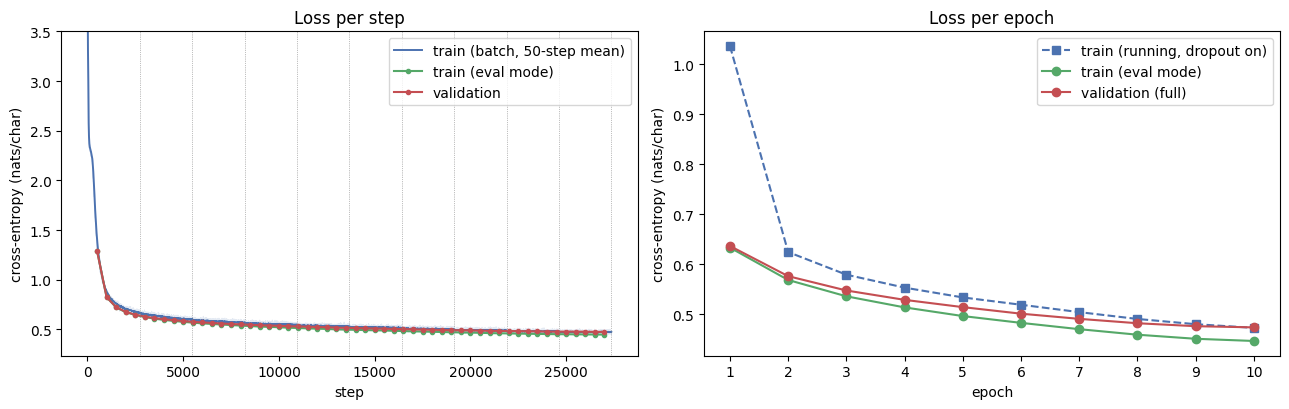

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
smooth = steps_df["loss"].rolling(50, min_periods=1).mean()
ax.plot(steps_df["step"], steps_df["loss"], color="#4C72B0", alpha=0.15, lw=0.6)
ax.plot(steps_df["step"], smooth, color="#4C72B0", lw=1.4, label="train (batch, 50-step mean)")
if len(evals_df):
    ax.plot(evals_df["step"], evals_df["train_loss"], "o-", ms=3, color="#55A868", label="train (eval mode)")
    ax.plot(evals_df["step"], evals_df["val_loss"], "o-", ms=3, color="#C44E52", label="validation")
for s in epochs_df["step"]:
    ax.axvline(s, color="gray", lw=0.5, ls=":")
ax.set_ylim(top=min(3.5, steps_df["loss"].max()))
ax.set_xlabel("step")
ax.set_ylabel("cross-entropy (nats/char)")
ax.set_title("Loss per step")
ax.legend()

ax = axes[1]
ax.plot(epochs_df["epoch"], epochs_df["train_loss_running"], "s--", color="#4C72B0", label="train (running, dropout on)")
ax.plot(epochs_df["epoch"], epochs_df["train_loss"], "o-", color="#55A868", label="train (eval mode)")
ax.plot(epochs_df["epoch"], epochs_df["val_loss"], "o-", color="#C44E52", label="validation (full)")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy (nats/char)")
ax.set_title("Loss per epoch")
ax.set_xticks(epochs_df["epoch"])
ax.legend()

plt.tight_layout()
plt.savefig(PLOT_DIR / "loss_curves.png", dpi=130)
plt.show()

### 4.2 Gradient Norm and Training Stability

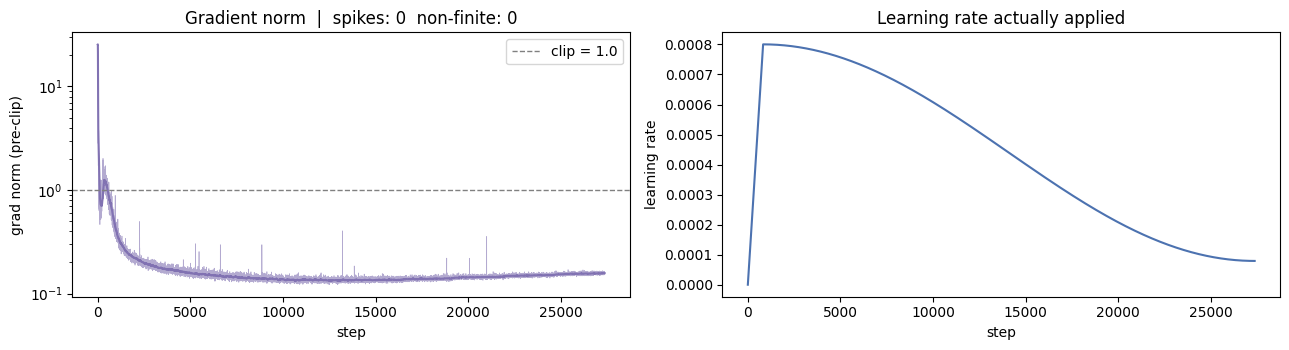

2026-10-05 23:18:09 | INFO    | stability {"grad_norm_mean": 0.1541293633648369, "grad_norm_median": 0.14485493302345276, "grad_norm_p99": 0.34087206125259445, "grad_norm_max": 25.5321044921875, "clipped_step_frac": 0.010562865497076024, "loss_spikes": 0, "nonfinite_steps": 0}


{'grad_norm_mean': 0.1541293633648369,
 'grad_norm_median': 0.14485493302345276,
 'grad_norm_p99': 0.34087206125259445,
 'grad_norm_max': 25.5321044921875,
 'clipped_step_frac': 0.010562865497076024,
 'loss_spikes': 0,
 'nonfinite_steps': 0}

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

ax = axes[0]
ax.plot(steps_df["step"], steps_df["grad_norm"], color="#8172B2", lw=0.5, alpha=0.6)
ax.plot(steps_df["step"], steps_df["grad_norm"].rolling(100, min_periods=1).median(), color="#8172B2", lw=1.5)
ax.axhline(cfg.grad_clip, color="gray", ls="--", lw=1, label=f"clip = {cfg.grad_clip}")
for sp in monitor.spikes:
    ax.axvline(sp["step"], color="#C44E52", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("grad norm (pre-clip)")
ax.set_title(f"Gradient norm  |  spikes: {len(monitor.spikes)}  non-finite: {len(monitor.nonfinite)}")
ax.legend()

ax = axes[1]
ax.plot(steps_df["step"], steps_df["lr"], color="#4C72B0")
ax.set_xlabel("step")
ax.set_ylabel("learning rate")
ax.set_title("Learning rate actually applied")

plt.tight_layout()
plt.savefig(PLOT_DIR / "stability.png", dpi=130)
plt.show()

post_warm = steps_df[steps_df["step"] > warmup_steps]
stability = {
    "grad_norm_mean": float(post_warm["grad_norm"].mean()),
    "grad_norm_median": float(post_warm["grad_norm"].median()),
    "grad_norm_p99": float(post_warm["grad_norm"].quantile(0.99)),
    "grad_norm_max": float(steps_df["grad_norm"].max()),
    "clipped_step_frac": float((steps_df["grad_norm"] > cfg.grad_clip).mean()),
    "loss_spikes": len(monitor.spikes),
    "nonfinite_steps": len(monitor.nonfinite),
}
log.info("stability " + json.dumps(stability))
stability

## 5. Text Generation

### 5.1 Decoding

Generation is autoregressive. The prompt is prefixed with `<|eos|>` so the model knows a new story is starting. At each step the last `block_size` characters go through the model, and the next character is picked in one of two ways:

- **Greedy** (`temperature = 0`): the argmax.
- **Temperature sampling**: sample from $\mathrm{softmax}(z / \tau)$, with optional top-k truncation.

`<unk>` is never sampled. Generation stops at `<|eos|>` or at `max_new_tokens`.

In [ ]:
@torch.no_grad()
def generate(net, prompts, max_new_tokens=600, temperature=0.8, top_k=None, stop_at_eos=True):
    net.eval()
    encoded = [[EOS_ID] + encode(p) for p in prompts]
    assert len({len(e) for e in encoded}) == 1, "batched prompts must have equal length"
    idx = torch.tensor(encoded, device=device)
    done = torch.zeros(len(prompts), dtype=torch.bool, device=device)
    for _ in range(max_new_tokens):
        with amp_ctx():
            logits, _ = net(idx[:, -cfg.block_size:])
        logits = logits[:, -1, :].float()
        logits[:, UNK_ID] = float("-inf")
        if temperature == 0:
            nxt = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k is not None:
                kth = torch.topk(logits, top_k).values[:, [-1]]
                logits = logits.masked_fill(logits < kth, float("-inf"))
            nxt = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)
        if stop_at_eos:
            done |= nxt.squeeze(1) == EOS_ID
            if done.all():
                break
    texts = []
    for row, prompt in zip(idx.tolist(), prompts):
        gen = row[len(encoded[0]):]
        if stop_at_eos and EOS_ID in gen:
            gen = gen[:gen.index(EOS_ID)]
        texts.append(prompt + decode(gen))
    return texts

### 5.2 Load the Best Checkpoint

In [ ]:
best_ckpt = torch.load(CKPT_DIR / "ckpt_best.pt", map_location=device)
raw_model.load_state_dict(best_ckpt["model"])
raw_model.eval()
log.info(f"loaded ckpt_best.pt (epoch {best_ckpt['epoch']}, step {best_ckpt['step']}, "
         f"val_loss {best_ckpt['metrics']['val_loss']:.4f})")

2026-10-05 23:18:09 | INFO    | loaded ckpt_best.pt (epoch 10, step 27360, val_loss 0.4742)


### 5.3 Greedy vs. Temperature Sampling

In [ ]:
PROMPTS = [
    "Once upon a time",
    "One day, a little girl named Lily",
    "Tom and his dog went to the park.",
    "The sun was hot and the bird",
]
SETTINGS = [("greedy", 0.0, None), ("t=0.5", 0.5, None), ("t=0.8", 0.8, None), ("t=1.0, top-k 20", 1.0, 20), ("t=1.3", 1.3, None)]

set_seed(cfg.seed)
showcase = []
for prompt in PROMPTS:
    for name, temp, k in SETTINGS:
        text = generate(raw_model, [prompt], max_new_tokens=500, temperature=temp, top_k=k)[0]
        showcase.append({"prompt": prompt, "setting": name, "temperature": temp, "top_k": k, "text": text})

with open(SAMPLE_DIR / "showcase.txt", "w") as f:
    for s in showcase:
        f.write(f"### prompt={s['prompt']!r} setting={s['setting']}\n{s['text']}\n\n")

for s in showcase[: len(SETTINGS)]:
    print(f"── {s['setting']} " + "─" * 60)
    print(s["text"], "\n")

── greedy ────────────────────────────────────────────────────────────
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mommy and daddy. They were having so much fun that they didn't notice the sun was shining brightly.

Suddenly, Lily saw a big dog running towards her. She got scared and ran away. Her mommy and daddy came outside and saw her scared. They told her that the dog was just playing and that she should never play with the dog again.

Lily felt bad and wanted to make her mommy and dadd 

── t=0.5 ────────────────────────────────────────────────────────────
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she went to the park with her mom and saw a beautiful flower. It was so pretty and shiny. She asked her mom if she could pick it and her mom said yes.

Lily was so happy to have a new flower to pick. She took a big bite and it was so 

In [ ]:
for s in showcase[len(SETTINGS):]:
    if s["setting"] in ("greedy", "t=0.8"):
        print(f"── {s['setting']} | {s['prompt']!r} " + "─" * 30)
        print(s["text"], "\n")

── greedy | 'One day, a little girl named Lily' ──────────────────────────────
One day, a little girl named Lily went to the park with her mom. They saw a big tree with a hole in it. Lily wanted to climb the hole to get the hole. Her mom said, "Lily, it's too high. You can sit on the tree and watch the birds."

Lily did not like the hole. She wanted to see the birds and the flowers. She said, "No, mom, I want to climb the hole. It's too high."

Her mom said, "Lily, you can do it. You just need to be careful and stay close to the tree. It's very high."

Lily did not listen to her mom. She said, "I don't wa 

── t=0.8 | 'One day, a little girl named Lily' ──────────────────────────────
One day, a little girl named Lily went to the park with her mom. They saw a big slide and Lily wanted to try it. She climbed up the ladder and slid down very fast. But then, she slipped and fell down. She hurt her knee and started crying.

Her mom tried to help her, but she also knew it was important to he

### 5.4 Generation Throughput

Two figures are measured. **Single-stream** speed is how fast one story is written (latency-bound). **Batched** speed is 32 stories generated in parallel (throughput-bound). The generator has no KV-cache, so it recomputes the whole context window at every step; these numbers are a conservative lower bound.

In [ ]:
def time_generation(batch, n_tokens=400):
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    generate(raw_model, ["Once upon a time"] * batch, max_new_tokens=n_tokens, temperature=1.0, stop_at_eos=False)
    if device == "cuda":
        torch.cuda.synchronize()
    return batch * n_tokens / (time.perf_counter() - t0)


time_generation(1, 20)
gen_tok_per_s_single = time_generation(1)
gen_tok_per_s_batched = time_generation(32)
log.info(f"generation tok/s single={gen_tok_per_s_single:,.0f} batched32={gen_tok_per_s_batched:,.0f}")
print(f"single stream: {gen_tok_per_s_single:,.0f} chars/s   batched x32: {gen_tok_per_s_batched:,.0f} chars/s")

2026-10-05 23:20:06 | INFO    | generation tok/s single=96 batched32=2,182
single stream: 96 chars/s   batched x32: 2,182 chars/s


## 6. Evaluation Metrics

### 6.1 Loss-Based Metrics on the Best Checkpoint

These are computed with dropout off, over the **full** validation set and the training set (all of it unless `final_train_eval_batches` is set).

- Perplexity = $e^{\mathrm{CE}}$
- Bits-per-character = $\mathrm{CE} / \ln 2$
- Generalization gap = val CE − train CE

In [ ]:
final_train_starts = eval_starts(train_data, cfg.block_size, cfg.batch_size, cfg.final_train_eval_batches, seed=4)
final_train = evaluate(model, train_data, final_train_starts)
final_val = evaluate(model, val_data, val_full)

loss_metrics = {
    "train_ce": final_train["loss"],
    "val_ce": final_val["loss"],
    "train_ppl": math.exp(final_train["loss"]),
    "val_ppl": math.exp(final_val["loss"]),
    "train_bpc": final_train["loss"] / math.log(2),
    "val_bpc": final_val["loss"] / math.log(2),
    "gen_gap": final_val["loss"] - final_train["loss"],
    "gen_gap_ratio": final_val["loss"] / final_train["loss"],
    "train_top1": final_train["acc"],
    "val_top1": final_val["acc"],
}
log.info("final_metrics " + json.dumps(loss_metrics))
pd.Series(loss_metrics).round(4).to_frame("best checkpoint")

2026-10-05 23:21:09 | INFO    | final_metrics {"train_ce": 0.44756866803076883, "val_ce": 0.4742034477909116, "train_ppl": 1.564503729622205, "val_ppl": 1.6067338402279294, "train_bpc": 0.645705097825269, "val_bpc": 0.6841309625003967, "gen_gap": 0.02663477976014278, "gen_gap_ratio": 1.0595099292301482, "train_top1": 0.8543668825026841, "val_top1": 0.8473530790231524}


,best checkpoint
train_ce,0.4476
val_ce,0.4742
train_ppl,1.5645
val_ppl,1.6067
train_bpc,0.6457
val_bpc,0.6841
gen_gap,0.0266
gen_gap_ratio,1.0595
train_top1,0.8544
val_top1,0.8474


### 6.1.1 Where the Remaining Errors Are

Top-1 accuracy is split by the kind of character being predicted:

- **word start**: a letter that follows a space, a newline, a quote or `<|eos|>`, i.e. choosing the next word.
- **inside word**: a letter that follows another letter, i.e. spelling a word that has already started.
- **space / punctuation**: everything else.

In [ ]:
@torch.no_grad()
def accuracy_by_position(net, data, starts):
    was_training = net.training
    net.eval()
    span = torch.arange(cfg.block_size + 1, device=data.device)
    boundary = torch.tensor([char_to_idx[c] for c in ' \n"' if c in char_to_idx] + [EOS_ID], device=device)
    letters = torch.tensor([i for ch, i in char_to_idx.items() if ch.isalpha()], device=device)
    stats = {k: [0, 0] for k in ("word start", "inside word", "space / punctuation")}
    for i in range(0, len(starts), cfg.batch_size):
        chunk = data[starts[i:i + cfg.batch_size, None] + span].long()
        x, y = chunk[:, :-1], chunk[:, 1:]
        with amp_ctx():
            logits, _ = net(x)
        hit = logits.argmax(-1) == y
        is_letter = torch.isin(y, letters)
        after_boundary = torch.isin(x, boundary)
        groups = {"word start": is_letter & after_boundary,
                  "inside word": is_letter & ~after_boundary,
                  "space / punctuation": ~is_letter}
        for k, m in groups.items():
            stats[k][0] += (hit & m).sum().item()
            stats[k][1] += m.sum().item()
    net.train(was_training)
    total = sum(n for _, n in stats.values())
    return {k: {"top1": c / max(1, n), "share_of_targets": n / total} for k, (c, n) in stats.items()}


position_acc = accuracy_by_position(model, val_data, val_quick)
log.info("position_accuracy " + json.dumps(position_acc))
pd.DataFrame(position_acc).T.round(4)

2026-10-05 23:21:10 | INFO    | position_accuracy {"word start": {"top1": 0.5632501912060811, "share_of_targets": 0.1955169677734375}, "inside word": {"top1": 0.9203412286394116, "share_of_targets": 0.5643310546875}, "space / punctuation": {"top1": 0.9052425247480717, "share_of_targets": 0.2401519775390625}}


,top1,share_of_targets
word start,0.5633,0.1955
inside word,0.9203,0.5643
space / punctuation,0.9052,0.2402


### 6.2 Generation Diversity and Repetition

Three sets of text are compared:

- **Model, τ = 0.8:** 64 stories sampled from scratch, each starting from `<|eos|>` alone (the main setting).
- **Model, greedy:** 16 stories continued greedily from the first five words of 16 held-out validation stories. Greedy decoding is deterministic, so it needs different prompts to give different stories.
- **Real validation stories:** 64 stories, as a reference.

The metrics:

- **Distinct-n**: unique word n-grams ÷ total word n-grams, pooled over a set (Li et al., 2016). Words are lower-cased alphabetic tokens. Distinct-n falls as more text is pooled, so every set is cut to the **same word budget**, the size of the smallest set, before it is computed. Without this, the comparison isn't fair.
- **Repeated 4-gram rate**: within each sample, the share of word 4-grams that already occurred earlier in that sample, averaged over samples. A value near 0 means no copying loops.
- **Invented-word rate**: the share of generated words that never appear in the training set. This is specific to a character-level model, which can spell words that don't exist.

In [ ]:
WORD_RE = re.compile(r"[A-Za-z']+")


def words(text):
    return [w.lower() for w in WORD_RE.findall(text)]


def ngrams(tokens, n):
    return list(zip(*(tokens[i:] for i in range(n))))


def take_budget(texts, budget):
    out, used = [], 0
    for t in texts:
        w = words(t)[: budget - used]
        if not w:
            break
        out.append(w)
        used += len(w)
    return out


def distinct_n(word_lists, n):
    grams = [g for w in word_lists for g in ngrams(w, n)]
    return len(set(grams)) / max(1, len(grams))


def repeated_ngram_rate(text, n=4):
    grams = ngrams(words(text), n)
    return 1 - len(set(grams)) / len(grams) if grams else 0.0


token_counts = Counter(m.group() for m in WORD_RE.finditer(train_text))
train_vocab_words = {w.lower() for w in token_counts}


def invented_words(text):
    return [w for w in words(text) if w.strip("'") and w not in train_vocab_words]


def diversity_report(texts, budget):
    total_words = sum(len(words(t)) for t in texts)
    pooled = take_budget(texts, budget)
    return {
        "distinct_1": distinct_n(pooled, 1),
        "distinct_2": distinct_n(pooled, 2),
        "distinct_3": distinct_n(pooled, 3),
        "rep_4gram": float(np.mean([repeated_ngram_rate(t) for t in texts])),
        "invented_word_rate": sum(len(invented_words(t)) for t in texts) / max(1, total_words),
        "mean_chars": float(np.mean([len(t) for t in texts])),
        "word_budget": budget,
    }

In [ ]:
set_seed(cfg.seed + 1)
main_samples = []
for _ in range(4):
    main_samples += generate(raw_model, [""] * 16, max_new_tokens=800, temperature=0.8)

greedy_prompts = [" ".join(s.split()[:5]) for s in val_stories[-16:]]
greedy_samples = [generate(raw_model, [p], max_new_tokens=800, temperature=0.0)[0] for p in greedy_prompts]

reference = val_stories[:64]
pools = {"model (t=0.8)": main_samples, "model (greedy)": greedy_samples, "real val stories": reference}
budget = min(sum(len(words(t)) for t in texts) for texts in pools.values())
diversity = {name: diversity_report(texts, budget) for name, texts in pools.items()}
with open(SAMPLE_DIR / "unconditional_t0.8.txt", "w") as f:
    f.write("\n\n<|eos|>\n\n".join(main_samples))
log.info("diversity " + json.dumps(diversity))
pd.DataFrame(diversity).round(4)

2026-10-05 23:23:56 | INFO    | diversity {"model (t=0.8)": {"distinct_1": 0.21178555604785113, "distinct_2": 0.6546184738955824, "distinct_3": 0.8687640449438202, "rep_4gram": 0.013521506902059766, "invented_word_rate": 0.00032772558444395895, "mean_chars": 715.40625, "word_budget": 2257}, "model (greedy)": {"distinct_1": 0.12538768276473194, "distinct_2": 0.3788487282463186, "distinct_3": 0.5042696629213483, "rep_4gram": 0.05920441773392385, "invented_word_rate": 0.0, "mean_chars": 696.875, "word_budget": 2257}, "real val stories": {"distinct_1": 0.24280017722640673, "distinct_2": 0.7230151650312221, "distinct_3": 0.9182757072294566, "rep_4gram": 0.010912034363928172, "invented_word_rate": 0.0008294166436273154, "mean_chars": 863.625, "word_budget": 2257}}


,model (t=0.8),model (greedy),real val stories
distinct_1,0.2118,0.1254,0.2428
distinct_2,0.6546,0.3788,0.7230
distinct_3,0.8688,0.5043,0.9183
rep_4gram,0.0135,0.0592,0.0109
invented_word_rate,0.0003,0.0000,0.0008
mean_chars,715.4062,696.8750,863.6250
word_budget,2257.0000,2257.0000,2257.0000
